<!-- @q -->
## Problem 1 

Using the data in the `2019_Yellow_Taxi_Trip_Data.csv` file, calculate summary statistics for the `fare_amount`, `tip_amount`, `tolls_amount`, and `total_amount` columns:

In [1]:
# loading the data 

import pandas as pd 
import numpy as np 

df = pd.read_csv("data/2019_Yellow_Taxi_Trip_Data.csv")

df[["fare_amount", "tip_amount", "tolls_amount","total_amount"]].describe()

,fare_amount,tip_amount,tolls_amount,total_amount
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,15.106313,2.634494,0.623447,22.564659
std,13.954762,3.409800,6.437507,19.209255
min,-52.000000,0.000000,-6.120000,-65.920000
25%,7.000000,0.000000,0.000000,12.375000
50%,10.000000,2.000000,0.000000,16.300000
75%,16.000000,3.250000,0.000000,22.880000
max,176.000000,43.000000,612.000000,671.800000


<!-- @q -->
## Problem 2

Isolate the `fare_amount`, `tip_amount`, `tolls_amount`, and `total_amount` for the longest trip by distance (`trip_distance`):

In [2]:
df.loc[df["trip_distance"].idxmax(),["fare_amount","tip_amount","tolls_amount"]]


fare_amount     176.0
tip_amount      18.29
tolls_amount     6.12
Name: 8338, dtype: object

<!-- @q -->
## Problem 3 

Read in the meteorite data from the `Meteorite_Landings.csv` file, rename the `mass (g)` column to `mass`, and drop all the latitude and longitude columns. Sort the result by mass in descending order.

In [3]:
df_meteorite = pd.read_csv("data/Meteorite_Landings.csv")

df_meteorite.rename(columns={"mass (g)": "mass"}, inplace=True)

df_meteorite.columns


Index(['name', 'id', 'nametype', 'recclass', 'mass', 'fall', 'year', 'reclat',
       'reclong', 'GeoLocation'],
      dtype='object')

<!-- @q -->
## Problem 4

Using the meteorite data from the `Meteorite_Landings.csv` file, update the `year` column to only contain the year, convert it to a numeric data type, and create a new column indicating whether the meteorite was observed falling before 1970. Set the index to the `id` column and extract all the rows with IDs between 10,036 and 10,040 (inclusive) with `loc[]`.

**Hint 1**: Use `year.str.slice()` to grab a substring.

**Hint 2**: Make sure to sort the index before using `loc[]` to select the range.

In [4]:
# df_meteorite.head()

df_meteorite['year'] = pd.to_numeric(df_meteorite["year"].astype(str).str[:4],errors="coerce")

In [5]:
df_meteorite["before_1970"] = df_meteorite["year"] < 1970

In [6]:
df_meteorite = df_meteorite.set_index('id').sort_index()

df_meteorite.loc[10036:10040]

,name,nametype,recclass,mass,fall,year,reclat,reclong,GeoLocation,before_1970
id,,,,,,,,,,
10036,Enigma,Valid,H4,94.0,Found,NaN,31.33333,-82.31667,"(31.33333, -82.31667)",False
10037,Enon,Valid,"Iron, ungrouped",763.0,Found,NaN,39.86667,-83.95000,"(39.86667, -83.95)",False
10038,Enshi,Valid,H5,8000.0,Fell,NaN,30.30000,109.50000,"(30.3, 109.5)",False
10039,Ensisheim,Valid,LL6,127000.0,Fell,NaN,47.86667,7.35000,"(47.86667, 7.35)",False


**BONUS**: There's a data entry error in the `year` column. Can you find it?

In [7]:
df_meteorite_1 = df_meteorite['year'].dropna()

# dropped the NA values 

There's a meteorite that was reportedly found in the future:

In [8]:
df_future = df_meteorite[df_meteorite["year"] > 2010]



_This meteorite actually was found in 2010 (more information [here](https://www.lpi.usra.edu/meteor/metbull.php?code=57150))._

<!-- @q -->
## Problem 5

Using the taxi trip data in the `2019_Yellow_Taxi_Trip_Data.csv` file, resample the data to an hourly frequency based on the dropoff time. Calculate the total `trip_distance`, `fare_amount`, `tolls_amount`, and `tip_amount`, then find the 5 hours with the most tips.

In [9]:
df.head()

df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])


In [10]:
df = df.set_index('tpep_dropoff_datetime')

In [11]:
hourly = df.resample('H')[['trip_distance','fare_amount','tolls_amount','tip_amount']].sum()

/tmp/ipykernel_2513/1946630008.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly = df.resample('H')[['trip_distance','fare_amount','tolls_amount','tip_amount']].sum()


In [12]:
hourly.sort_values('tip_amount', ascending=False).head(5)


,trip_distance,fare_amount,tolls_amount,tip_amount
tpep_dropoff_datetime,,,,
2019-10-23 16:00:00,10676.95,67797.76,699.04,12228.64
2019-10-23 17:00:00,16052.83,70131.91,4044.04,12044.03
2019-10-23 18:00:00,3104.56,11565.56,1454.67,1907.64
2019-10-23 15:00:00,14.34,213.50,0.00,51.75
2019-10-23 19:00:00,98.59,268.00,24.48,25.74


<!-- @q -->
## Problem 6

Using the TSA traveler throughput data in the `tsa_melted_holiday_travel.csv` file, create box plots for traveler throughput for each year in the data. Hint: Pass `kind='box'` into the `plot()` method to generate box plots.

In [13]:
df_tsa = pd.read_csv("data/tsa_melted_holiday_travel.csv")

df_tsa.head()

,date,year,travelers,holiday
0,2019-01-01,2019,2126398.0,New Year's Day
1,2019-01-02,2019,2345103.0,New Year's Day
2,2019-01-03,2019,2202111.0,NaN
3,2019-01-04,2019,2150571.0,NaN
4,2019-01-05,2019,1975947.0,NaN


In [ ]:
import matplotlib.pylab as plt

df_tsa.boxplot(column="travelers", by='year')
plt.xlabel("Year")
plt.ylabel("Travelers")


<!-- @q -->
## Problem 7
Using the TSA traveler throughput data in the `tsa_melted_holiday_travel.csv` file, create a heatmap that shows the 2019 TSA median traveler throughput by day of week and month.

In [ ]:
import seaborn as sns

In [ ]:
df_tsa['date'] = pd.to_datetime(df_tsa['date'])
df_tsa_2019 = df_tsa[df_tsa['year'] == 2019]

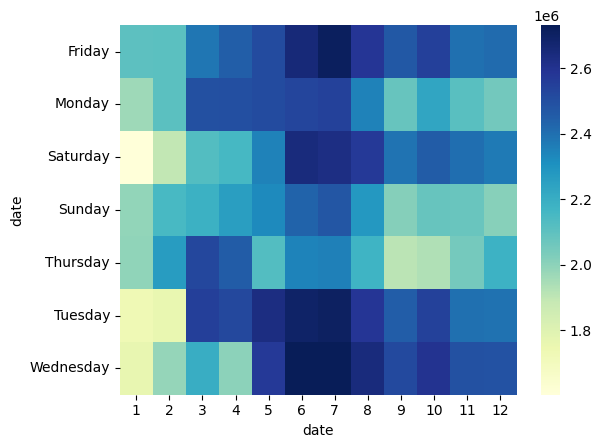

In [ ]:
heatmap_data = (
    df_tsa_2019.groupby([df_tsa_2019['date'].dt.day_name(),
                     df_tsa_2019['date'].dt.month])['travelers']
    .median()
    .unstack()
)

sns.heatmap(heatmap_data, cmap="YlGnBu")
plt.show()